## Pull hourly weather data — per-station (regional)

Same 4 stations as `pullWeather.ipynb` but saves each station as its own prefixed columns instead of averaging. Output is `weather_hourly_regional.csv` with 20 columns (`{station}_{variable}`).

| Station | Key | Location | Lat | Lon |
|---|---|---|---|---|
| Sacramento | `sacramento` | NorCal inland | 38.58 | -121.49 |
| San Jose | `sanjose` | Bay Area | 37.34 | -121.89 |
| Fresno | `fresno` | Central Valley | 36.74 | -119.79 |
| Los Angeles | `la` | SoCal | 34.05 | -118.24 |

**Variables per station:** `temperature_c`, `precipitation_mm`, `solar_radiation_wm2`, `windspeed_ms`, `humidity_pct`

In [1]:
import requests
import pandas as pd
import os
import matplotlib.pyplot as plt

START_DATE = '2019-01-01'
END_DATE   = '2024-12-31'
OUTPUT     = '../../data/raw/weather_hourly_regional.csv'

STATIONS = {
    'sacramento': (38.58, -121.49),
    'sanjose':    (37.34, -121.89),
    'fresno':     (36.74, -119.79),
    'la':         (34.05, -118.24),
}

VARIABLES = [
    'temperature_2m',
    'precipitation',
    'shortwave_radiation',
    'windspeed_10m',
    'relativehumidity_2m',
]

VAR_RENAME = {
    'temperature_2m':      'temperature_c',
    'precipitation':       'precipitation_mm',
    'shortwave_radiation':  'solar_radiation_wm2',
    'windspeed_10m':        'windspeed_ms',
    'relativehumidity_2m':  'humidity_pct',
}

### 1. Fetch each station

In [2]:
def fetch_station(key, lat, lon):
    print(f'Fetching {key} ({lat}, {lon})...')
    r = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude':        lat,
            'longitude':       lon,
            'start_date':      START_DATE,
            'end_date':        END_DATE,
            'hourly':          ','.join(VARIABLES),
            'timezone':        'America/Los_Angeles',
            'wind_speed_unit': 'ms',
        },
        timeout=60
    )
    r.raise_for_status()
    df = pd.DataFrame(r.json()['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    df = df.rename(columns=VAR_RENAME)
    # Prefix every column with the station key
    df.columns = [f'{key}_{col}' for col in df.columns]
    print(f'  → {len(df):,} rows, {len(df.columns)} columns')
    return df


frames = [fetch_station(key, lat, lon) for key, (lat, lon) in STATIONS.items()]

Fetching sacramento (38.58, -121.49)...
  → 52,608 rows, 5 columns
Fetching sanjose (37.34, -121.89)...
  → 52,608 rows, 5 columns
Fetching fresno (36.74, -119.79)...
  → 52,608 rows, 5 columns
Fetching la (34.05, -118.24)...
  → 52,608 rows, 5 columns


### 2. Concatenate columns & save

In [3]:
weather = pd.concat(frames, axis=1)
weather.index.name = 'datetime'

os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)
weather.to_csv(OUTPUT)
print(f'Saved {len(weather):,} rows × {len(weather.columns)} columns → {OUTPUT}')
print('Columns:', weather.columns.tolist())

Saved 52,608 rows × 20 columns → ../../data/raw/weather_hourly_regional.csv
Columns: ['sacramento_temperature_c', 'sacramento_precipitation_mm', 'sacramento_solar_radiation_wm2', 'sacramento_windspeed_ms', 'sacramento_humidity_pct', 'sanjose_temperature_c', 'sanjose_precipitation_mm', 'sanjose_solar_radiation_wm2', 'sanjose_windspeed_ms', 'sanjose_humidity_pct', 'fresno_temperature_c', 'fresno_precipitation_mm', 'fresno_solar_radiation_wm2', 'fresno_windspeed_ms', 'fresno_humidity_pct', 'la_temperature_c', 'la_precipitation_mm', 'la_solar_radiation_wm2', 'la_windspeed_ms', 'la_humidity_pct']


### 3. QC — temperature spread across stations

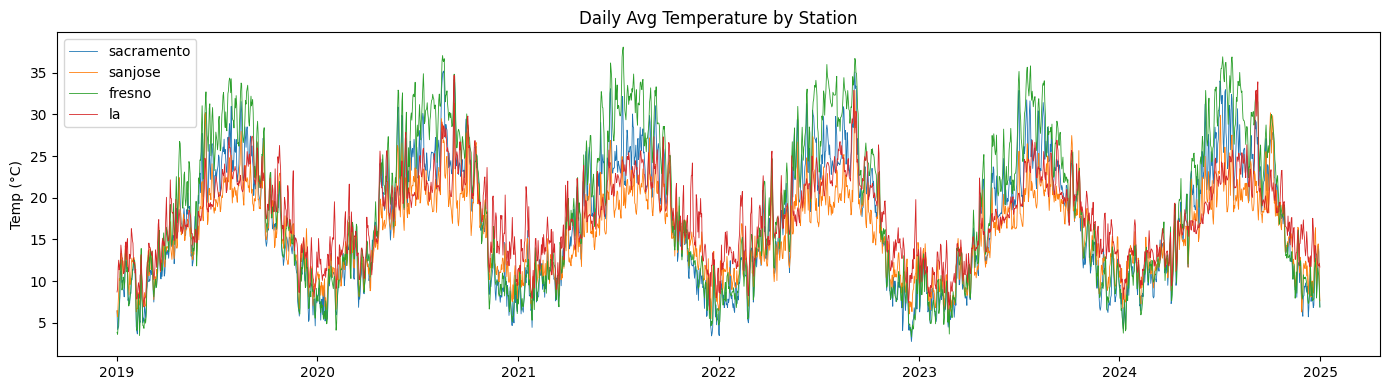

In [4]:
temp_cols = [f'{s}_temperature_c' for s in STATIONS]
daily = weather[temp_cols].resample('D').mean()

fig, ax = plt.subplots(figsize=(14, 4))
for col in temp_cols:
    ax.plot(daily.index, daily[col], linewidth=0.6, label=col.replace('_temperature_c', ''))
ax.set_ylabel('Temp (°C)')
ax.set_title('Daily Avg Temperature by Station')
ax.legend()
plt.tight_layout()
plt.show()